In [1]:
%pip install torch torch_geometric scikit-learn pandas matplotlib seaborn networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.datasets import Planetoid

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp314-cp314-win_amd64.whl.metadata (21 kB)
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/124.1 MB 2.1 MB/s eta 0:01:01
   ---------------------------------------- 1.0/124.1 MB 2.9 MB/s eta 0:00:43
    --------------------------------------- 2.4/124.1 MB 3.6 MB/s eta 0:00:34
   - -------------------------------------- 3.7/124.1 MB 4.3 MB/s eta 0:00:28
   - -------------------------------------- 4.5/124.1 MB 4.6 MB/s eta 0:00:27
   - -------------------------------------- 5.5/124.1 MB 4.5 MB/s eta 0:

c:\Users\obaid\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\obaid\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

In [3]:
dataset = Planetoid(root="data/Planetoid", name="Cora")

Processing...
Done!


In [4]:
data = dataset[0]

print(f"Number of Papers (Nodes): {data.num_nodes}")
print(f"Number of Citation (Edges): {data.num_edges}")
print(f"Feature per paper: {data.num_node_features}")
print(f"Number of topics: {dataset.num_classes}")
print(f"Training Papers: {data.train_mask.sum()}")
print(f"Validation Papers: {data.val_mask.sum()}")
print(f"Testing Papers: {data.test_mask.sum()}")

Number of Papers (Nodes): 2708
Number of Citation (Edges): 10556
Feature per paper: 1433
Number of topics: 7
Training Papers: 140
Validation Papers: 500
Testing Papers: 1000


<Axes: xlabel='None', ylabel='count'>

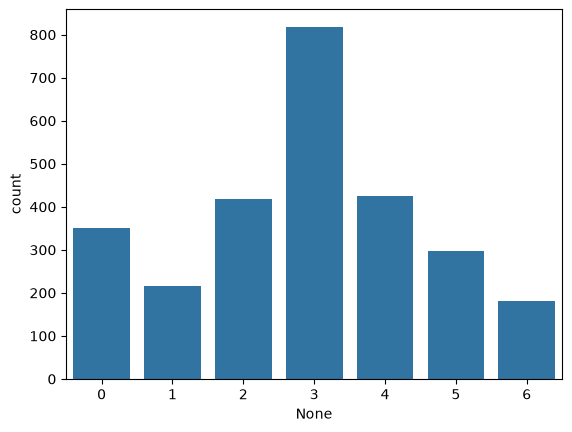

In [5]:
topic_counts = pd.Series(data.y.numpy()).value_counts().sort_index()

sns.barplot(x=topic_counts.index, y=topic_counts)

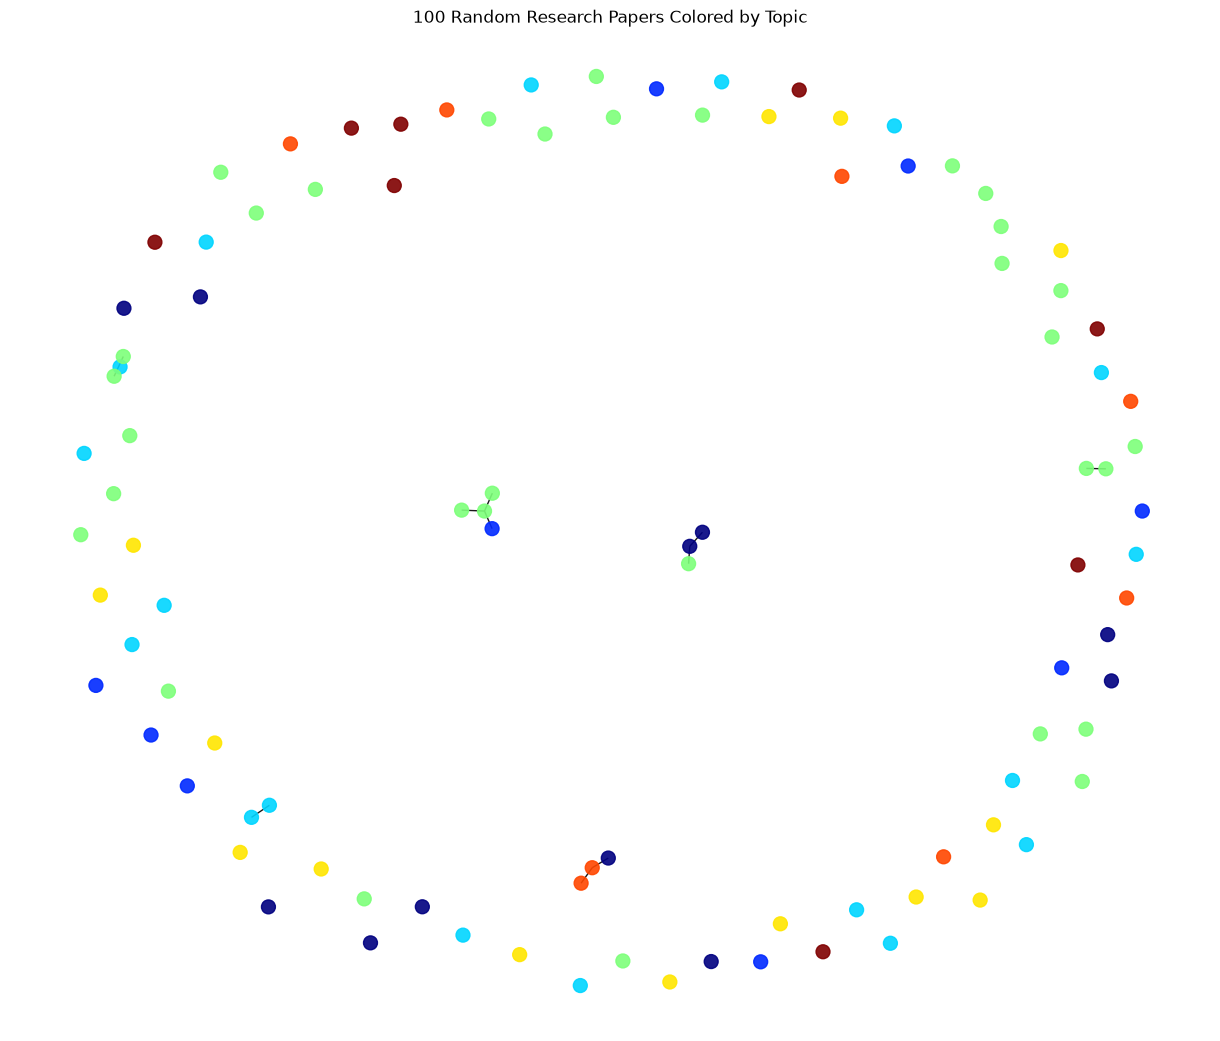

In [6]:
from torch_geometric.utils import to_networkx

import networkx as nx
import random
import matplotlib.pyplot as plt


SEED = 12345

# Convert the PyTorch Geometric data object to a NetworkX graph
G = to_networkx(data, to_undirected=True)

# Select 100 random nodes
random.seed(SEED)
sampled_nodes = random.sample(list(G.nodes()), 100)

# Create a graph using only those nodes
sample_graph = G.subgraph(sampled_nodes)

# Get the topic of each node
node_colors = [
    data.y[node].item()
    for node in sample_graph.nodes()
]

# Create positions for the nodes
pos = nx.spring_layout(sample_graph, seed=SEED)

# Draw the graph
plt.figure(figsize=(12, 10))

nx.draw(
    sample_graph,
    pos,
    node_color=node_colors,
    cmap=plt.cm.jet,
    node_size=100,
    alpha=0.9,
    with_labels=False
)

plt.title("100 Random Research Papers Colored by Topic")
plt.axis("off")
plt.show()

In [7]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [8]:
X_binary = data.x.numpy()
y = data.y.numpy()

In [9]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfTransformer()
X_tfidf = tfidf.fit_transform(X_binary).toarray()
X_baseline = X_tfidf

train_idx = data.train_mask.numpy()
val_idx = data.val_mask.numpy()
test_idx = data.test_mask.numpy()

X_train, y_train = X_baseline[train_idx], y[train_idx]
X_test, y_test = X_baseline[test_idx],y[test_idx]

rf = RandomForestClassifier(n_estimators=100,max_features="sqrt",class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [10]:
#Evaluation
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='macro')
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Macro-F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")

Accuracy: 0.5810
Macro-F1: 0.5698


<Axes: >

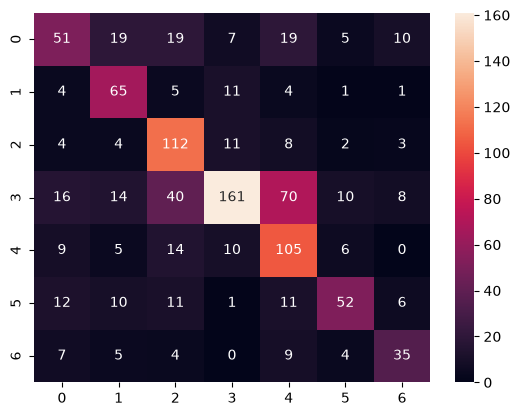

In [11]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d")

In [12]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
import torch

class SimpleGCN(nn.Module):
  def __init__(self, input_dim,hidden_dim,output_dim,dropout=0.5):
    super().__init__()
    self.conv1 = GCNConv(input_dim, hidden_dim)
    self.conv2 = GCNConv(hidden_dim,output_dim)
    self.dropout = dropout

  def forward(self,x,edge_index):
    x = self.conv1(x,edge_index)
    x = F.relu(x)
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = self.conv2(x,edge_index)
    return x

model = SimpleGCN(
    input_dim = data.num_features,
    hidden_dim = 32,
    output_dim = dataset.num_classes,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)

SimpleGCN(
  (conv1): GCNConv(1433, 32)
  (conv2): GCNConv(32, 7)
)


In [13]:
#Training of GCN Model
def train_one_epoch():
    model.train() #Training
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index) #x-> 2708 x 7
    loss = F.cross_entropy(logits[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(mask):
    model.eval()
    logits = model(data.x, data.edge_index) # Pass full edge_index to the model
    predictions = logits.argmax(dim=1)
    accuracy = (predictions[mask] == data.y[mask]).float().mean().item() # Corrected accuracy calculation
    macro_f1 = f1_score(
        data.y[mask].numpy(),
        predictions[mask].numpy(),
        average="macro"
    )
    return accuracy, macro_f1, predictions

In [14]:
losses, train_accuracies, val_accuracies = [], [], []
best_val_accuracy = 0.0
best_state = None

epoch_without_improvement = 0
patience = 20 #Stop i no improvement for this many epochs

for epoch in range(1, 201):
  loss = train_one_epoch()
  train_accuracy,_,_ = evaluate(data.train_mask)
  val_accuracy,_,_ = evaluate(data.val_mask)

  losses.append(loss)
  train_accuracies.append(train_accuracy)
  val_accuracies.append(val_accuracy) #0.70

  if val_accuracy > best_val_accuracy: #0.56 > 0.70
    best_val_accuracy = val_accuracy
    best_state = model.state_dict()
    epoch_without_improvement = 0

  else:
    epoch_without_improvement += 1

  if epoch_without_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  if epoch == 1 or epoch % 10 == 0:
    print(f"Epoch: {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} |Best Val Acc: {best_val_accuracy:.4f}")

model.load_state_dict(best_state)
gcn_accuracy, gcn_f1, gcn_pred = evaluate(data.test_mask)

print(f"\nGCN test accuracy: {gcn_accuracy:.3f}")
print(f"GCN test macro-F1: {gcn_f1:.3f}")

Epoch: 001 | Loss: 1.9476 | Train Acc: 0.6857 | Val Acc: 0.4460 |Best Val Acc: 0.4460
Epoch: 010 | Loss: 0.4659 | Train Acc: 0.9857 | Val Acc: 0.7760 |Best Val Acc: 0.7780
Epoch: 020 | Loss: 0.0698 | Train Acc: 1.0000 | Val Acc: 0.7800 |Best Val Acc: 0.7820
Epoch: 030 | Loss: 0.0431 | Train Acc: 1.0000 | Val Acc: 0.7680 |Best Val Acc: 0.7820
Early stopping at epoch 31

GCN test accuracy: 0.778
GCN test macro-F1: 0.774


<Axes: >

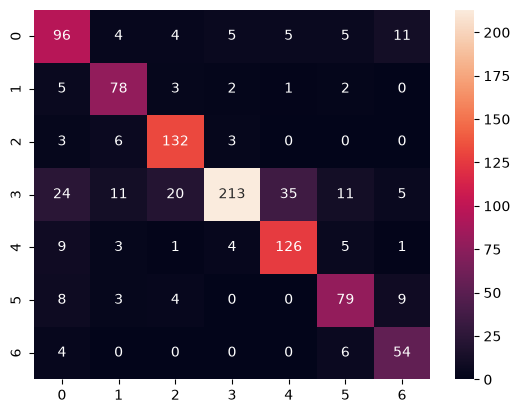

In [15]:
#Confusion MArix for GCN model.
sns.heatmap(
    confusion_matrix(data.y[data.test_mask].numpy(), gcn_pred[data.test_mask].numpy()),
    annot=True,
    fmt="d"
)

In [16]:
results = pd.DataFrame({
    "Model": ["Random Forest", "GCN"],
    "Accuracy": [rf_accuracy, gcn_accuracy],
    "Macro-F1": [rf_f1, gcn_f1]
})

In [17]:
results

,Model,Accuracy,Macro-F1
0,Random Forest,0.581,0.569807
1,GCN,0.778,0.773962


In [18]:
#ONNX -> Open Neural Network Exchange -> Model very fast and optimized.
import torch
%pip install onnxscript

#set the model to evaluation mode
model.eval()


#Create dummy input for ONNX export
#The input 'x' has shape [num_nodes, num_features]
#The input 'edge_index' has sahpe[2, edge_index]

x_dummy = data.x
edge_index_dummy = data.edge_index

onnx_file_path = "simple_gcn_cora.onnx"
torch.onnx.export(
    model,                                            #1. Trained Model.
    (x_dummy, edge_index_dummy),                      #2. Model input.
    onnx_file_path,                                   #3. Where to save the ONNX model.
    export_params = True,                             #4. Store the trained parameter weights inside the model file.
    opset_version=18,                                 #5. Changed opset_version to 18 to avoid version conversion issues.
    do_constant_folding=True,                         #6.Whether to execute constant folding for optimation
    input_names=['node_features', 'edge_indices'],    #7. input names
    output_names=['logits'],                          #8. Output names
    dynamic_axes={
        'node_features': {0: 'num_nodes'},            #9.Variable length for num_nodes
        'edge_indices': {1: 'num_edges'}              #10.Variable length for num_edges
    }
)

print(f"Model exported to {onnx_file_path}")

   ---------------------------------------- 0.0/754.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/754.2 kB ? eta -:--:--
   ------------- -------------------------- 262.1/754.2 kB ? eta -:--:--
   ---------------------------------------- 754.2/754.2 kB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.2 MB 3.3 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/17.2 MB 4.1 MB/s eta 0:00:04
   ----- ---------------------------------- 2.4/17.2 MB 4.3 MB/s eta 0:00:04
   -------- ------------------------------- 3.7/17.2 MB 4.7 MB/s eta 0:00:03
   ---------- ----------------------------- 4.5/17.2 MB 4.6 MB/s eta 0:00:03
   ------------ --------------------------- 5.5/17.2 MB 4.7 MB/s eta 0:00:03
   --------------- ------------------------ 6.8/17.2 MB 4.9 MB/s eta 0:00:03
   ----------------- ---------------------- 7.3/17.2 MB 4.8 MB/s eta 0:00:03
   ------------------ 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\obaid\AppData\Local\Temp\ipykernel_38544\3367659199.py:17: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0918 15:39:21.707000 38544 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::nms
W0918 15:39:21.709000 38544 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_align
W0918 15:39:21.711000 38544 site-packages\torch\onnx\_internal\exporter\_registration.py:107] torchvision is not installed. Skipping torchvision::roi_pool
W

[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleGCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to simple_gcn_cora.onnx
